In [39]:
#Import các thư viện cần thiết
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import warnings; warnings.filterwarnings(action='once')
import random
import math


# Load the data from the CSV file
newdf = pd.read_csv('batdongsan.com.vn.csv')
print(newdf.head())  # Print the first few rows to check the data

         id  month                     project  \
0  28086120   12.0  Vinhomes Smart City Đại Mỗ   
1  28088954   12.0               Goldmark City   
2  28097966   12.0        Chung cư IEC Tứ Hiệp   
3  27895887   12.0         Vinhomes D'Capitale   
4  28056031   12.0           The Zen Residence   

                                            investor  square  bedrooms  \
0                                  Tập đoàn Vingroup    60.0       3.0   
1  Công ty TNHH Thương mại - Quảng cáo - Xây dựng...   121.0       3.0   
2                                                NaN    70.0       2.0   
3                               Tân Hoàng Minh Group    39.0       1.0   
4                  Công ty TNHH Gamuda Land Việt Nam    97.0       3.0   

   bathrooms direction   balcony     district        ward   price  
0        1.0  Đông-Nam   Tây-Bắc  nam tu liem      dai mo  1560.0  
1        2.0       NaN       NaN  bac tu liem    phu dien  3300.0  
2        2.0   Tây-Bắc  Đông-Nam    thanh tri     

In [40]:
newdf.columns

Index(['id', 'month', 'project', 'investor', 'square', 'bedrooms', 'bathrooms',
       'direction', 'balcony', 'district', 'ward', 'price'],
      dtype='object')

In [41]:
newdf.info()  # Get information about the DataFrame

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 81163 entries, 0 to 81162
Data columns (total 12 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   id         81163 non-null  int64  
 1   month      81162 non-null  float64
 2   project    78097 non-null  object 
 3   investor   65453 non-null  object 
 4   square     81162 non-null  float64
 5   bedrooms   81162 non-null  float64
 6   bathrooms  81162 non-null  float64
 7   direction  51086 non-null  object 
 8   balcony    54426 non-null  object 
 9   district   81162 non-null  object 
 10  ward       79506 non-null  object 
 11  price      81162 non-null  float64
dtypes: float64(5), int64(1), object(6)
memory usage: 7.4+ MB


In [42]:
print(newdf.shape)
newdf.head(10)

print(sum(newdf['month'] == 0))

(81163, 12)
0


c:\Users\ADMIN\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


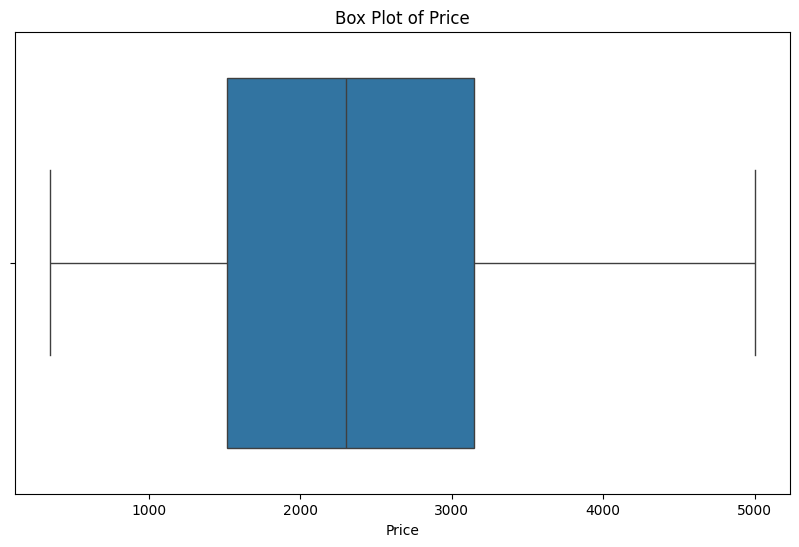

In [43]:
# box plot for 'price' field
plt.figure(figsize=(10, 6))
sns.boxplot(x=newdf['price'])
plt.title('Box Plot of Price')
plt.xlabel('Price')
plt.show()

c:\Users\ADMIN\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


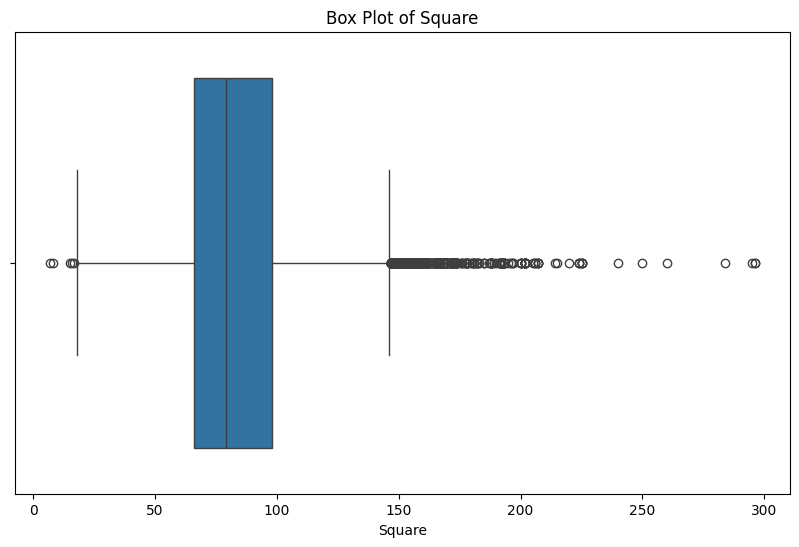

In [44]:
#box plot for 'square' field

plt.figure(figsize=(10, 6))
sns.boxplot(x = newdf['square'])
plt.title('Box Plot of Square')
plt.xlabel('Square')
plt.show()

c:\Users\ADMIN\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


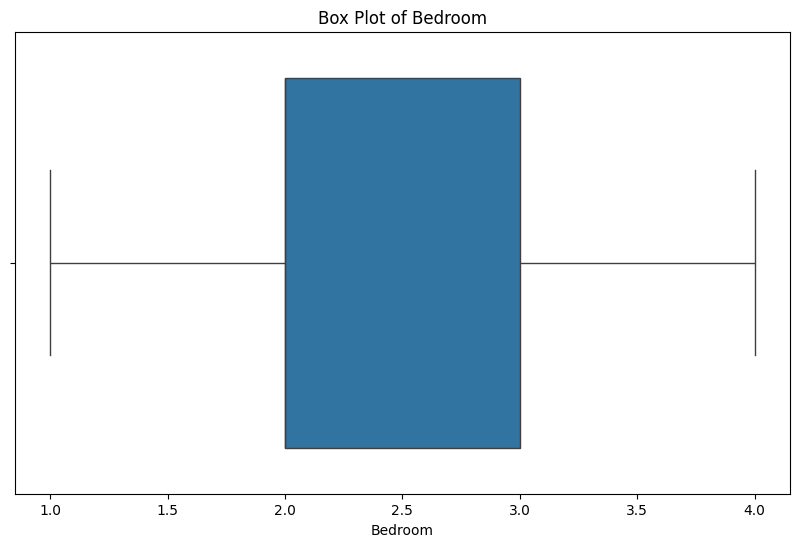

In [45]:
#box plot for bedroom field
plt.figure(figsize=(10, 6))
sns.boxplot(x = newdf['bedrooms'])
plt.title('Box Plot of Bedroom')
plt.xlabel('Bedroom')
plt.show()

c:\Users\ADMIN\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


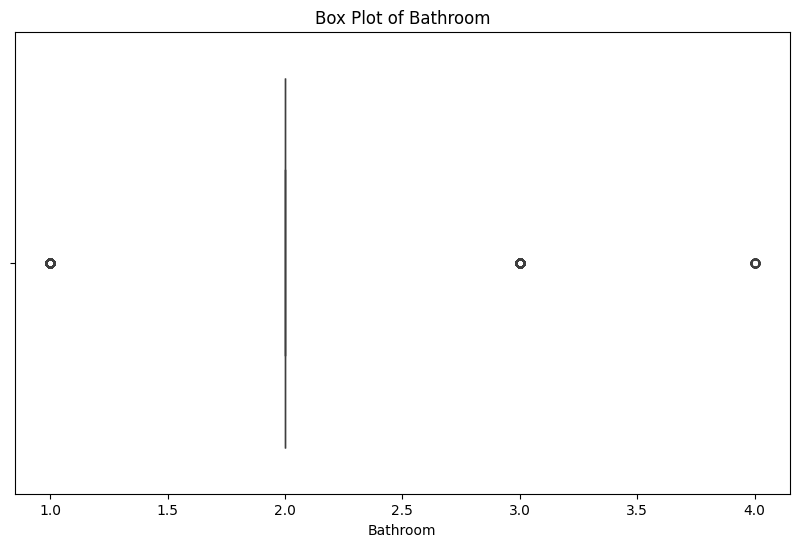

In [46]:
#boxplot for bathrooms field
plt.figure(figsize=(10, 6))
sns.boxplot(x = newdf['bathrooms'])
plt.title('Box Plot of Bathroom')
plt.xlabel('Bathroom')
plt.show()


In [47]:
print(sum(newdf['month'] == 0))
newdf['month'] = newdf['month'].fillna(0.0)

#delete rows where month is 0
newdf = newdf[newdf['month'] != 0]
newdf.shape
# newdf.sort_values(by = 'id', inplace = True)
# newdf

0


(81162, 12)

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_4948\2116006392.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels(df1['month'], rotation=60, horizontalalignment='right')


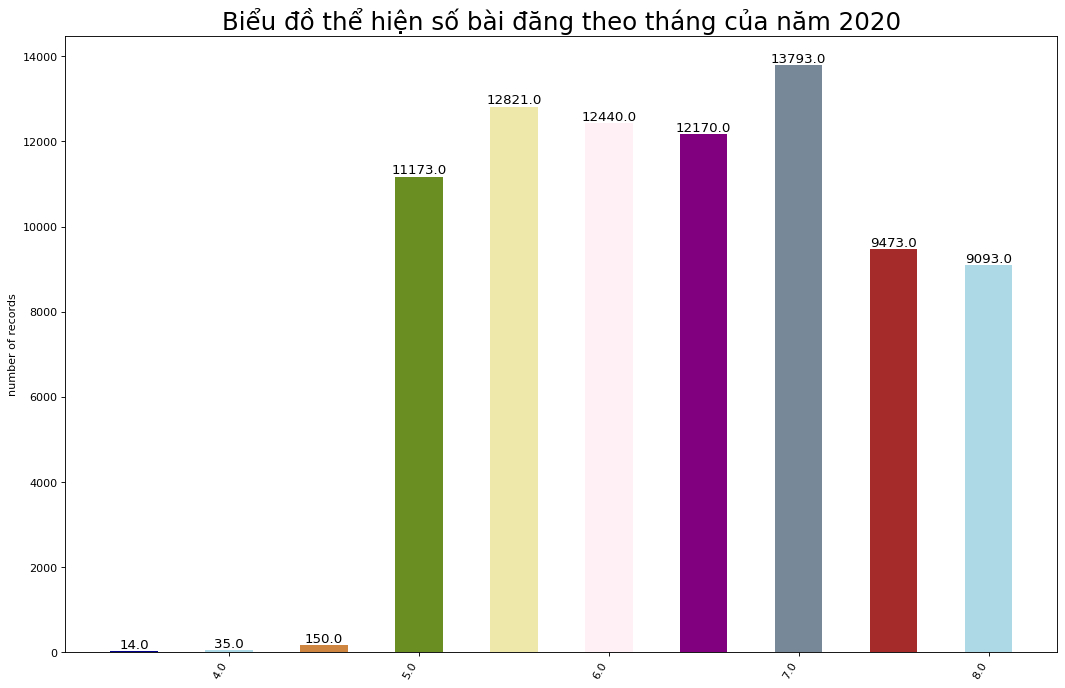

In [48]:
df1 = newdf.groupby('month').size().reset_index(name = 'number_of_records')
n = df1['month'].unique().__len__()+1

all_colors = list(plt.cm.colors.cnames.keys())
random.seed(100)
c = random.choices(all_colors, k=n)

plt.figure(figsize=(16,10), dpi= 80)
plt.bar(df1['month'], df1['number_of_records'], color=c, width=.5)

for i, val in enumerate(df1['number_of_records'].values):
    plt.text(df1['month'].iloc[i], val, float(val), horizontalalignment='center',verticalalignment='bottom', fontdict={'fontweight':500, 'size':12})

plt.gca().set_xticklabels(df1['month'], rotation=60, horizontalalignment='right')
plt.title("Biểu đồ thể hiện số bài đăng theo tháng của năm 2020", fontsize=22)
plt.ylabel('number of records')
plt.show()

In [49]:
newdf

,id,month,project,investor,square,bedrooms,bathrooms,direction,balcony,district,ward,price
0,28086120,12.0,Vinhomes Smart City Đại Mỗ,Tập đoàn Vingroup,60.0,3.0,1.0,Đông-Nam,Tây-Bắc,nam tu liem,dai mo,1560.0
1,28088954,12.0,Goldmark City,Công ty TNHH Thương mại - Quảng cáo - Xây dựng...,121.0,3.0,2.0,NaN,NaN,bac tu liem,phu dien,3300.0
2,28097966,12.0,Chung cư IEC Tứ Hiệp,NaN,70.0,2.0,2.0,Tây-Bắc,Đông-Nam,thanh tri,tu hiep,1106.0
3,27895887,12.0,Vinhomes D'Capitale,Tân Hoàng Minh Group,39.0,1.0,1.0,Đông-Nam,Đông-Nam,cau giay,trung hoa,1500.0
4,28056031,12.0,The Zen Residence,Công ty TNHH Gamuda Land Việt Nam,97.0,3.0,2.0,NaN,NaN,hoang mai,hoang liet,2900.0
...,...,...,...,...,...,...,...,...,...,...,...,...
81157,25598786,5.0,Khu đô thị Kim Văn - Kim Lũ (Golden Silk),Công ty CP Xây dựng số 2 - Vinaconex2,65.0,2.0,2.0,NaN,Tây-Bắc,hoang mai,dai kim,1300.0
81158,22545821,5.0,Goldsilk Complex,Công ty CP Bất động sản Hanovid,78.0,2.0,2.0,Tây-Bắc,Đông-Nam,ha dong,van phuc,2000.0
81159,25601798,5.0,A10-A14 Nam Trung Yên,Tổng Công ty Đầu Tư và Phát Triển Nhà Hà Nội -...,94.0,3.0,2.0,Tây-Nam,Tây-Bắc,cau giay,yen hoa,3214.8
81160,25603729,5.0,NaN,NaN,55.0,2.0,1.0,NaN,NaN,nam tu liem,my dinh 2,1550.0


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_4948\2933440000.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels(df2['month'], rotation=60, horizontalalignment='right')


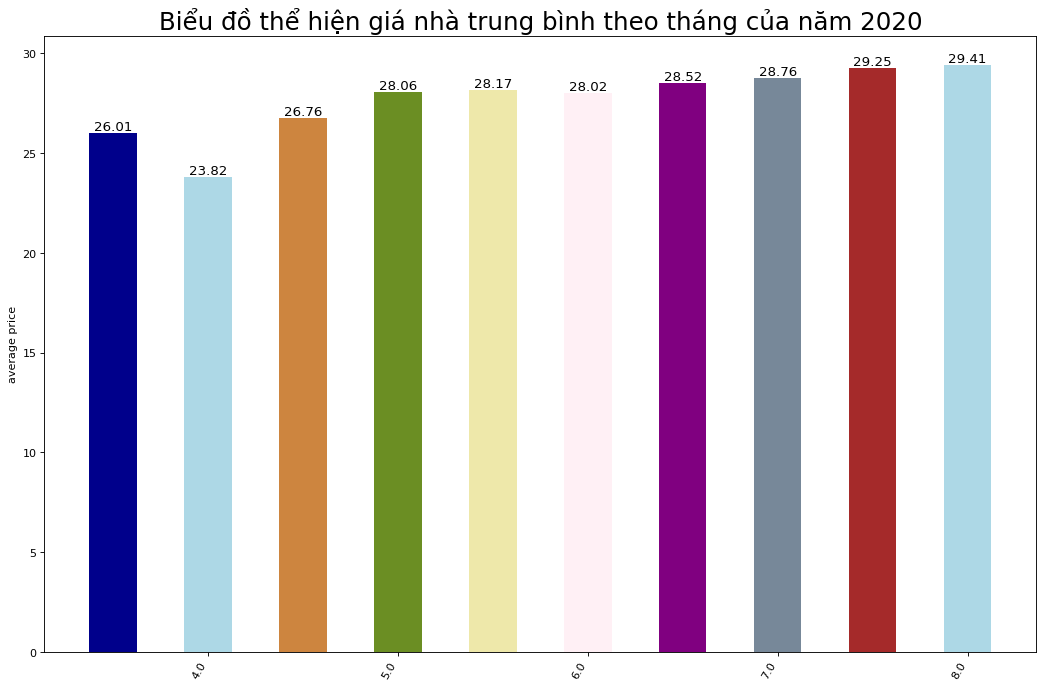

In [50]:
df2 = newdf.copy()
df2['priceperSquare'] = df2['price'] / df2['square']
df2 = df2.groupby('month')['priceperSquare'].mean().reset_index(name = 'average_price')
n = df2['month'].unique().__len__()+1
first = df2['month'][0]
df2
# print(first)

all_colors = list(plt.cm.colors.cnames.keys())
random.seed(100)
c = random.choices(all_colors, k=n)

plt.figure(figsize=(16,10), dpi= 80)
plt.bar(df2['month'], df2['average_price'], color=c, width=.5)

for i, val in enumerate(df2['average_price'].values):
    plt.text(i + first, val, float(f"{val:.2f}"), horizontalalignment='center',verticalalignment='bottom', fontdict={'fontweight':500, 'size':12})

plt.gca().set_xticklabels(df2['month'], rotation=60, horizontalalignment='right')
plt.title("Biểu đồ thể hiện giá nhà trung bình theo tháng của năm 2020", fontsize=22)
plt.ylabel('average price')
plt.show()

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_4948\1665114207.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dftmp.loc[dftmp['month'] == month, "priceperSquare"], label=f"Thang {month}", hist_kws={'alpha':.7}, kde_kws={'linewidth':3})
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_4948\1665114207.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwa

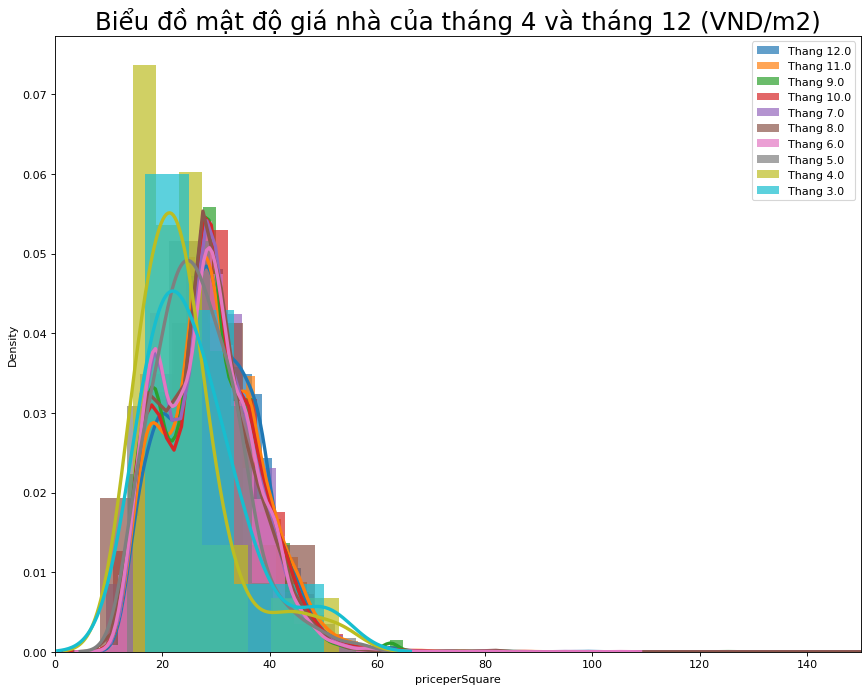

In [51]:
dftmp = newdf.copy()
dftmp['priceperSquare'] = dftmp['price'] / dftmp['square']

plt.figure(figsize=(13,10), dpi= 80)

for month in dftmp['month'].unique():
    sns.distplot(dftmp.loc[dftmp['month'] == month, "priceperSquare"], label=f"Thang {month}", hist_kws={'alpha':.7}, kde_kws={'linewidth':3})
# sns.distplot(dftmp.loc[dftmp['month'] == 12, "priceperSquare"],color="dodgerblue", label="Thang 12", hist_kws={'alpha':.7},kde_kws={'linewidth':3})
# sns.distplot(dftmp.loc[dftmp['month'] == 4, "priceperSquare"],color="orange", label="Thang 4", hist_kws={'alpha':.7}, kde_kws={'linewidth':3})

plt.xlim(0, 150)
plt.title('Biểu đồ mật độ giá nhà của tháng 4 và tháng 12 (VND/m2)',fontsize=22)
plt.legend()
plt.show()

In [52]:
newdf.columns

Index(['id', 'month', 'project', 'investor', 'square', 'bedrooms', 'bathrooms',
       'direction', 'balcony', 'district', 'ward', 'price'],
      dtype='object')

1.0 4158
2.0 45317
3.0 29543
4.0 2144


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_4948\117860434.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels(df3['bedrooms'], rotation=60, horizontalalignment='right')


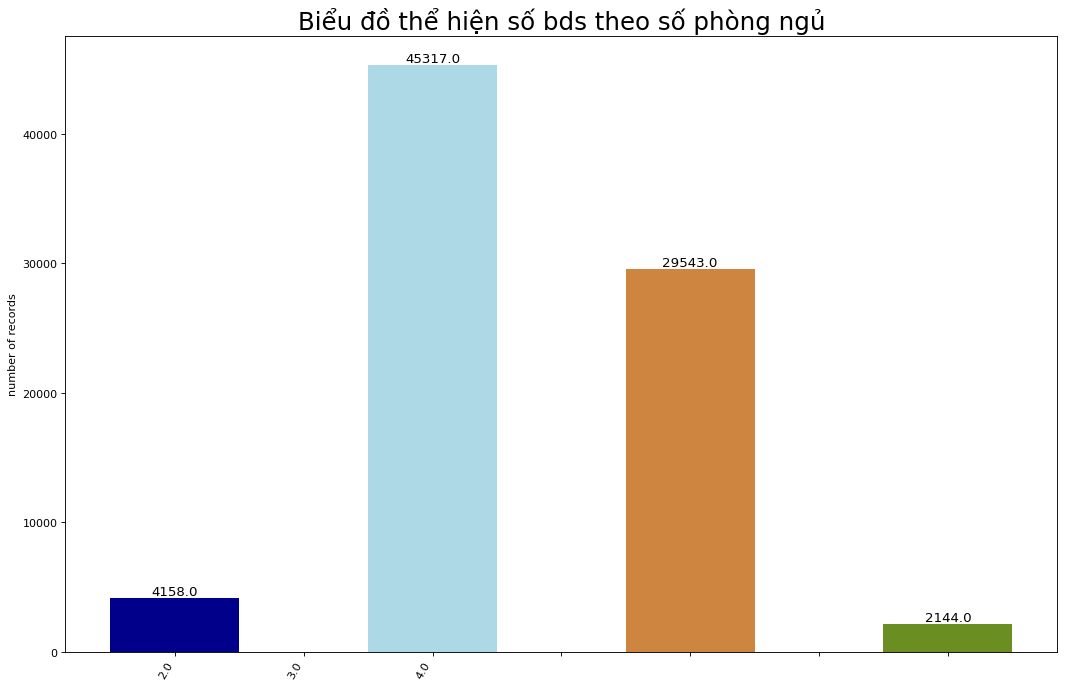

In [53]:
df3 = newdf.groupby('bedrooms').size().reset_index(name = 'number_of_records')
n = df3['bedrooms'].unique().__len__()+1
# print(first)

all_colors = list(plt.cm.colors.cnames.keys())
random.seed(100)
c = random.choices(all_colors, k=n)

plt.figure(figsize=(16,10), dpi= 80)
plt.bar(df3['bedrooms'], df3['number_of_records'], color=c, width=.5)

for i, val in enumerate(df3['number_of_records'].values):
    print(df3['bedrooms'].iloc[i], val)
    plt.text(df3['bedrooms'].iloc[i], val, float(val), horizontalalignment='center',verticalalignment='bottom', fontdict={'fontweight':500, 'size':12})

plt.gca().set_xticklabels(df3['bedrooms'], rotation=60, horizontalalignment='right')
plt.title("Biểu đồ thể hiện số bds theo số phòng ngủ", fontsize=22)
plt.ylabel('number of records')
plt.show()

In [54]:
df3

,bedrooms,number_of_records
0,1.0,4158
1,2.0,45317
2,3.0,29543
3,4.0,2144


['darkblue', 'lightblue', 'peru', 'olivedrab', 'palegoldenrod']


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_4948\2275568289.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels(df4['bedrooms'], rotation=60, horizontalalignment='right')


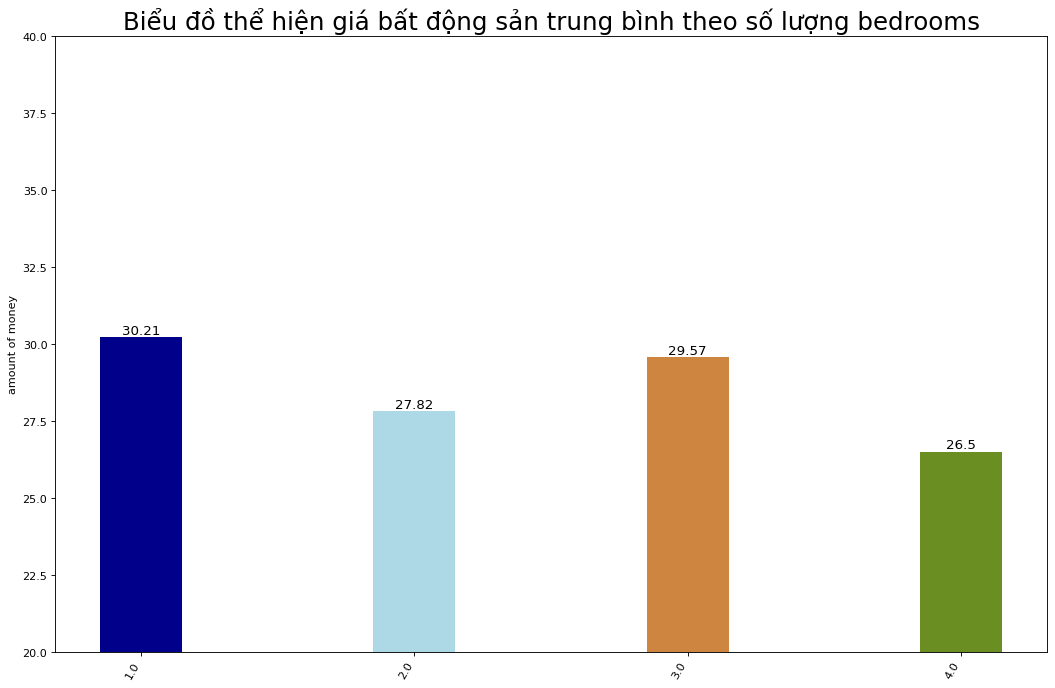

In [55]:
df4 = dftmp.groupby('bedrooms')['priceperSquare'].mean().reset_index(name='amount of money')
# df4['amount of money'] = df4['amount of money'].apply(lambda x : int(str(x).split('.')[0]))
df4['amount of money'] = df4['amount of money'].apply(lambda x : round(x, 2))
df4['bedrooms'] = df4['bedrooms'].apply(lambda x : str(x))
n = df4['bedrooms'].unique().__len__()+1

all_colors = list(plt.cm.colors.cnames.keys())
random.seed(100)
c = random.choices(all_colors, k=n)
print(c)
plt.figure(figsize=(16,10), dpi= 80)
plt.bar(df4['bedrooms'], df4['amount of money'], color=c, width=.3)
for i, val in enumerate(df4['amount of money'].values):
    plt.text(i, val, float(val), horizontalalignment='center',verticalalignment='bottom', fontdict={'fontweight':500, 'size':12})
plt.gca().set_xticklabels(df4['bedrooms'], rotation=60, horizontalalignment='right')
plt.title("Biểu đồ thể hiện giá bất động sản trung bình theo số lượng bedrooms", fontsize=22)
plt.ylim(20,40)
plt.ylabel('amount of money')
plt.show()



In [59]:
dftmp.head(5)

,id,month,project,investor,square,bedrooms,bathrooms,direction,balcony,district,ward,price,priceperSquare
0,28086120,12.0,Vinhomes Smart City Đại Mỗ,Tập đoàn Vingroup,60.0,3.0,1.0,Đông-Nam,Tây-Bắc,nam tu liem,dai mo,1560.0,26.000000
1,28088954,12.0,Goldmark City,Công ty TNHH Thương mại - Quảng cáo - Xây dựng...,121.0,3.0,2.0,NaN,NaN,bac tu liem,phu dien,3300.0,27.272727
2,28097966,12.0,Chung cư IEC Tứ Hiệp,NaN,70.0,2.0,2.0,Tây-Bắc,Đông-Nam,thanh tri,tu hiep,1106.0,15.800000
3,27895887,12.0,Vinhomes D'Capitale,Tân Hoàng Minh Group,39.0,1.0,1.0,Đông-Nam,Đông-Nam,cau giay,trung hoa,1500.0,38.461538
4,28056031,12.0,The Zen Residence,Công ty TNHH Gamuda Land Việt Nam,97.0,3.0,2.0,NaN,NaN,hoang mai,hoang liet,2900.0,29.896907


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_4948\2634125936.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels(df5['district'], rotation=60, horizontalalignment='right')


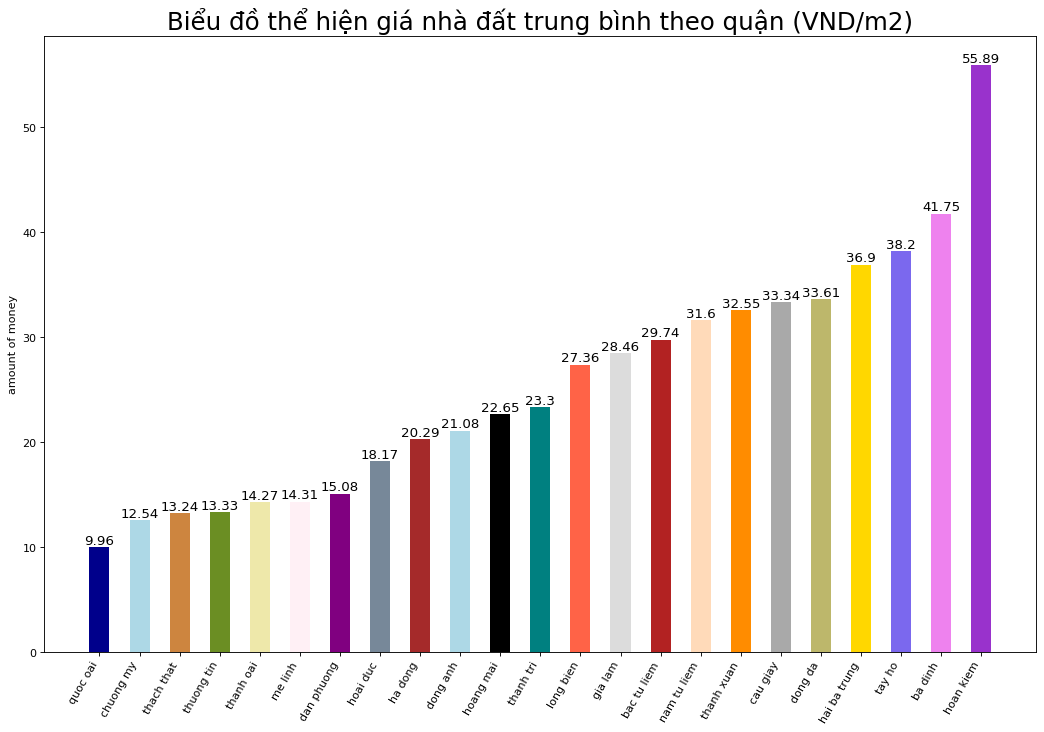

In [66]:
# • Giá nhà đất trung bình theo quận (VND/m2)
df5 = dftmp.groupby('district')['priceperSquare'].mean().reset_index(name='amount of money')
# df5['amount of money'] = df5['amount of money'].apply(lambda x : int(str(x).split('.')[0]))
df5['amount of money'] = df5['amount of money'].apply(lambda x : round(x, 2))
df5['district'] = df5['district'].apply(lambda x : str(x))
df5.sort_values(by = 'amount of money', inplace = True, ascending = True)
n = df5['district'].unique().__len__()+1

all_colors = list(plt.cm.colors.cnames.keys())
random.seed(100)
c = random.choices(all_colors, k=n)
plt.figure(figsize=(16,10), dpi= 80)
plt.bar(df5['district'], df5['amount of money'], color=c, width=.5)
for i, val in enumerate(df5['amount of money'].values):
    plt.text(i, val, float(val), horizontalalignment='center',verticalalignment='bottom', fontdict={'fontweight':500, 'size':12})
plt.gca().set_xticklabels(df5['district'], rotation=60, horizontalalignment='right')
plt.title("Biểu đồ thể hiện giá nhà đất trung bình theo quận (VND/m2)",fontsize=22)
plt.ylabel('amount of money')
# plt.ylim(25,35)
plt.show()



C:\Users\ADMIN\AppData\Local\Temp\ipykernel_4948\547296147.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels(df6['ward'], rotation=60, horizontalalignment='right')


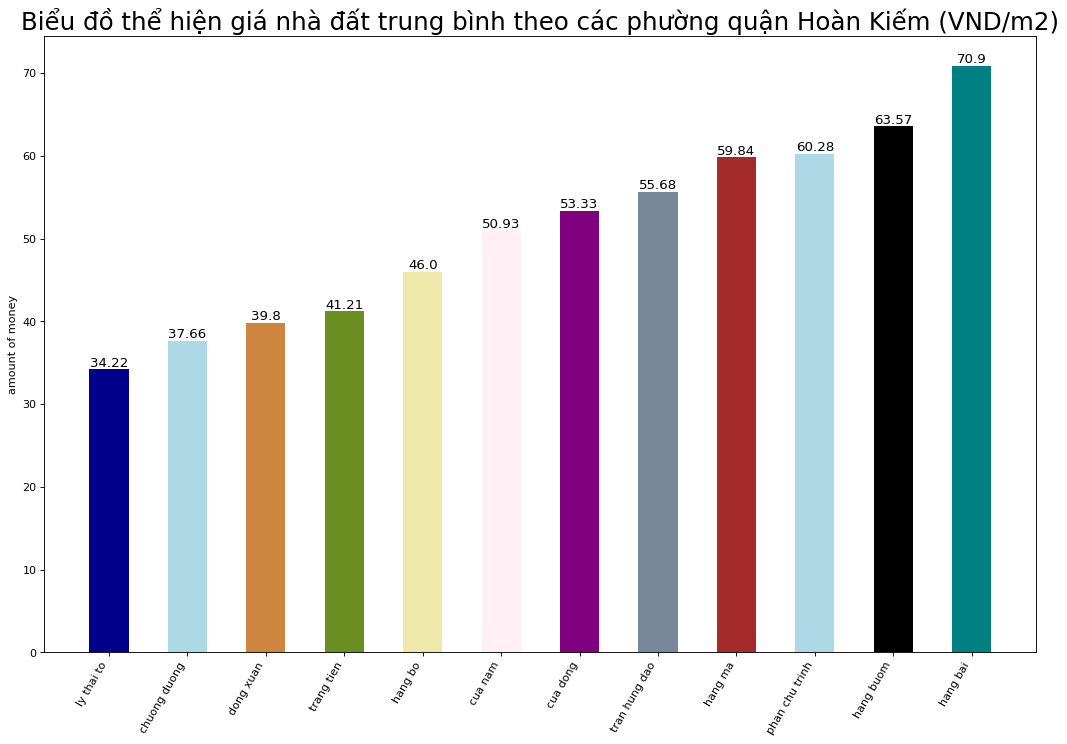

In [71]:
# • Giá nhà đất trung bình theo các phường quận Hoàn Kiếm (VND/m2)
df6 = dftmp[dftmp['district'] == 'hoan kiem'].groupby('ward')['priceperSquare'].mean().reset_index(name='amount of money')
df6['amount of money'] = df6['amount of money'].apply(lambda x : round(x, 2))
df6['ward'] = df6['ward'].apply(lambda x : str(x))
df6.sort_values(by = 'amount of money', inplace = True, ascending = True)
df6 
n = df6['ward'].unique().__len__()+1
all_colors = list(plt.cm.colors.cnames.keys())
random.seed(100)
c = random.choices(all_colors, k=n)

plt.figure(figsize=(16,10), dpi= 80)
plt.bar(df6['ward'], df6['amount of money'], color=c, width=.5)
for i, val in enumerate(df6['amount of money'].values):
    plt.text(i, val, float(val), horizontalalignment='center',verticalalignment='bottom', fontdict={'fontweight':500, 'size':12})
plt.gca().set_xticklabels(df6['ward'], rotation=60, horizontalalignment='right')
plt.title("Biểu đồ thể hiện giá nhà đất trung bình theo các phường quận Hoàn Kiếm (VND/m2)",fontsize=22)
plt.ylabel('amount of money')
# plt.ylim(25,35)
plt.show()

In [77]:
dftmp['investor'].nunique()

262

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_4948\4190825896.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels(df7['investor'], rotation=60, horizontalalignment='right')


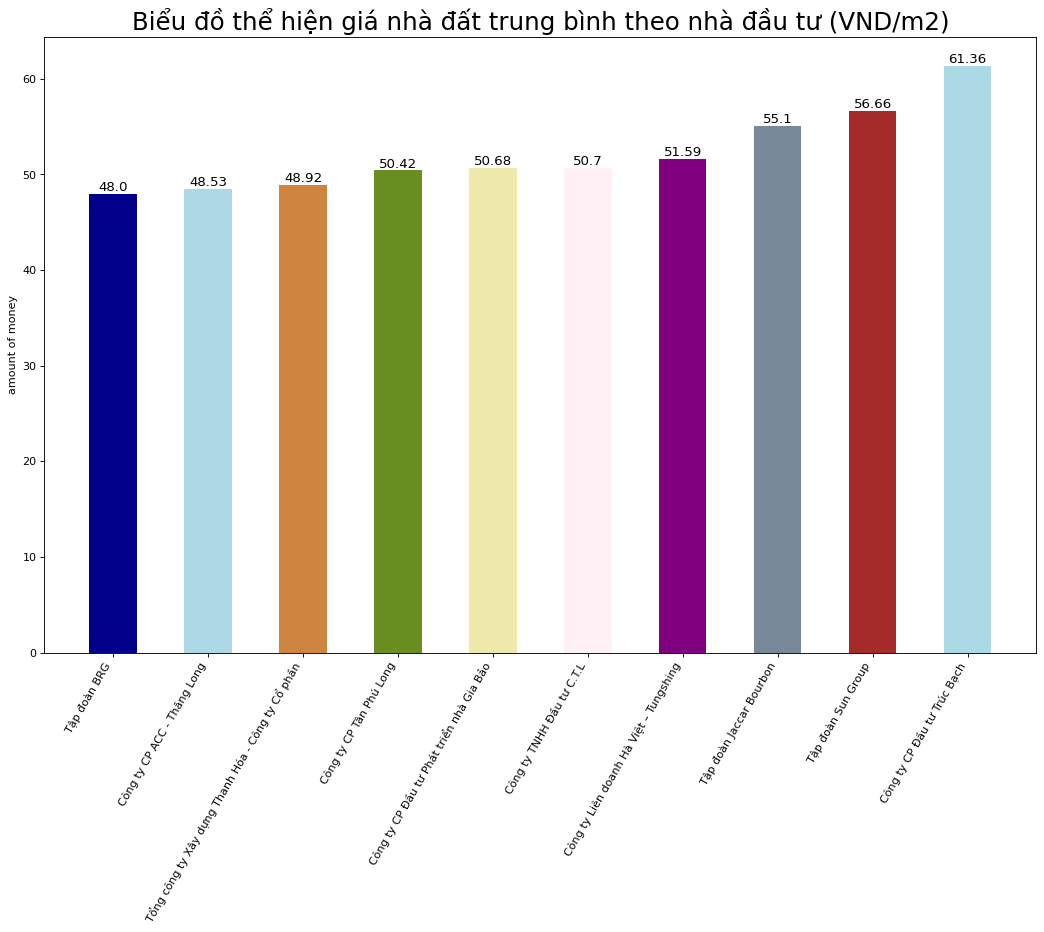

In [80]:
# • Giá nhà đất trung bình theo nhà đầu tư (VND/m2)
df7 = dftmp.groupby('investor')['priceperSquare'].mean().reset_index(name='amount of money')
df7['amount of money'] = df7['amount of money'].apply(lambda x : round(x, 2))
df7['investor'] = df7['investor'].apply(lambda x : str(x))
df7.sort_values(by = 'amount of money', inplace = True, ascending = True)   

# keep top 6 investors
df7 = df7.tail(10)
n = df7['investor'].unique().__len__()+1
all_colors = list(plt.cm.colors.cnames.keys())
random.seed(100)

#top 6 investors
c = random.choices(all_colors, k=n)
plt.figure(figsize=(16,10), dpi= 80)
plt.bar(df7['investor'], df7['amount of money'], color=c, width=.5)
for i, val in enumerate(df7['amount of money'].values):
    plt.text(i, val, float(val), horizontalalignment='center',verticalalignment='bottom', fontdict={'fontweight':500, 'size':12})
plt.gca().set_xticklabels(df7['investor'], rotation=60, horizontalalignment='right')
plt.title("Biểu đồ thể hiện giá nhà đất trung bình theo nhà đầu tư (VND/m2)",fontsize=22)
plt.ylabel('amount of money')
# plt.ylim(25,35)
plt.show()

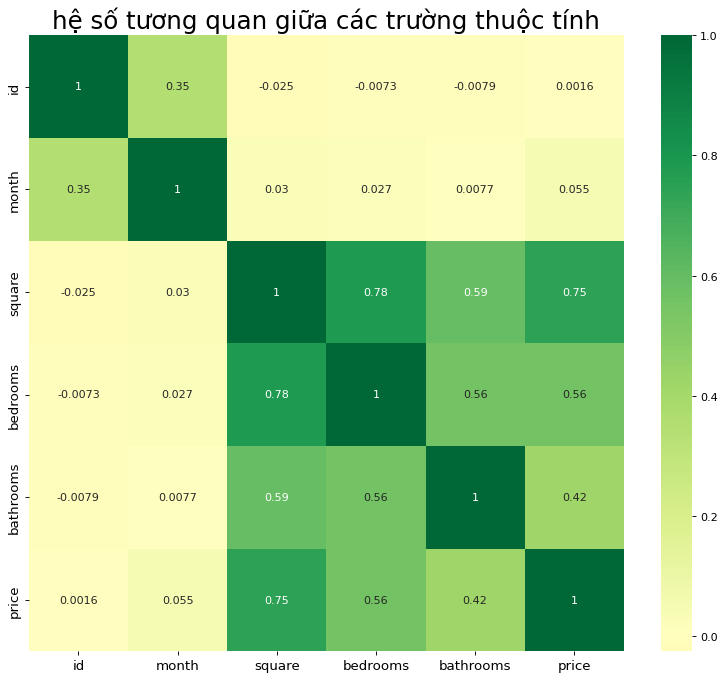

In [83]:
# Tương quan giữa các trường thuộc tính

# Select only numeric columns for correlation
numeric_df = newdf.select_dtypes(include=[np.number])

plt.figure(figsize=(12,10), dpi= 80)
sns.heatmap(numeric_df.corr(), xticklabels=numeric_df.corr().columns, yticklabels=numeric_df.corr().columns, cmap='RdYlGn', center=0, annot=True)
plt.title('hệ số tương quan giữa các trường thuộc tính', fontsize=22)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()